# Model 4: Hyperparameter-tuned CVAE

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# ==========================================
# 0. Upload + Load 2022–2024 NPZ DATA
# ==========================================
from google.colab import files
uploaded = files.upload()   # upload f1_2022_2024_data.npz from your laptop

npz_fname = list(uploaded.keys())[0]
print("Using NPZ file:", npz_fname)

data = np.load(npz_fname, allow_pickle=True)

X_all = data["X"]          # (N, T, F)  or  (N, W, T, F)
C_all = data["C"]          # team one-hot
y_all = data["y"]          # driver index
teams = data["teams"]
drivers = data["drivers"]

print("Loaded from NPZ:")
print("  X_all.shape:", X_all.shape)
print("  C_all.shape:", C_all.shape)
print("  y_all.shape:", y_all.shape)
print("  #teams:", len(teams))
print("  #drivers:", len(drivers))

# Base dataset (no batching/padding yet)
full_dataset = tf.data.Dataset.from_tensor_slices((X_all, C_all, y_all))


# ==========================================
# 1. Gradient Reversal
# ==========================================
class GradientReversal(layers.Layer):
    def __init__(self, lambd=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambd = lambd

    def call(self, x):
        lambd = self.lambd

        @tf.custom_gradient
        def _reverse(x):
            def grad(dy):
                return -lambd * dy
            return x, grad

        return _reverse(x)


# ==========================================
# 2. Semi-Supervised Adversarial CVAE
# ==========================================
class SemiSupervisedCVAE(Model):
    def __init__(
        self,
        seq_len,
        feature_dim,
        num_teams,
        num_drivers,
        latent_dim=10,
        cond_dim=8,
        gamma=20.0,        # ↑ stronger driver supervision
        lambda_adv=0.5,    # ↓ softer adversarial pressure
        beta_init=1.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.num_teams = num_teams
        self.num_drivers = num_drivers
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim
        self.gamma = gamma
        self.lambda_adv = lambda_adv

        # KL weight (will be set by BetaWarmupCallback)
        self.beta = tf.Variable(
            beta_init, trainable=False, dtype=tf.float32, name="beta"
        )

        # ---------------- Encoder: x -> (z_mean, z_log_var) ----------------
        x_in = layers.Input(shape=(seq_len, feature_dim), name="x_in")

        h = layers.Conv1D(32, 3, strides=2, padding="same", activation="relu")(x_in)
        h = layers.Conv1D(64, 3, strides=2, padding="same", activation="relu")(h)
        h = layers.Flatten()(h)
        h = layers.Dense(128, activation="relu")(h)

        z_mean = layers.Dense(latent_dim, name="z_mean")(h)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

        self.encoder = Model(x_in, [z_mean, z_log_var], name="encoder")

        # ---------------- Decoder: (z, c) -> x_hat ----------------
        z_in = layers.Input(shape=(latent_dim,), name="z_in")
        c_dec_in = layers.Input(shape=(num_teams,), name="c_dec_in")

        c_dec_emb = layers.Dense(cond_dim, activation="relu")(c_dec_in)
        dec_in = layers.Concatenate()([z_in, c_dec_emb])

        initial_len = seq_len // 4  # assumes seq_len divisible by 4
        h_dec = layers.Dense(initial_len * 64, activation="relu")(dec_in)
        h_dec = layers.Reshape((initial_len, 64))(h_dec)

        h_dec = layers.Conv1DTranspose(
            64, 3, strides=2, padding="same", activation="relu"
        )(h_dec)
        h_dec = layers.Conv1DTranspose(
            32, 3, strides=2, padding="same", activation="relu"
        )(h_dec)

        x_out = layers.Conv1D(
            feature_dim,
            3,
            padding="same",
            activation="sigmoid",
            name="x_recon",
        )(h_dec)

        self.decoder = Model([z_in, c_dec_in], x_out, name="decoder")

        # ---------------- Driver classifier: (z, c) -> driver logits --------
        z_cls_in = layers.Input(shape=(latent_dim,), name="z_for_driver")
        c_cls_in = layers.Input(shape=(num_teams,), name="c_for_driver")

        c_cls_emb = layers.Dense(cond_dim, activation="relu")(c_cls_in)
        cls_in = layers.Concatenate()([z_cls_in, c_cls_emb])

        h_cls = layers.Dense(64, activation="relu")(cls_in)
        d_logits = layers.Dense(
            num_drivers, activation="softmax", name="driver_logits"
        )(h_cls)

        self.driver_classifier = Model(
            [z_cls_in, c_cls_in],
            d_logits,
            name="driver_classifier",
        )

        # ---------------- Adversarial team classifier: GRL(z) -> team -------
        z_team_in = layers.Input(shape=(latent_dim,), name="z_for_team")
        grl = GradientReversal(lambd=lambda_adv, name="grad_reverse")(z_team_in)
        h_team = layers.Dense(32, activation="relu")(grl)
        t_logits = layers.Dense(
            num_teams, activation="softmax", name="team_logits"
        )(h_team)

        self.team_classifier = Model(
            z_team_in,
            t_logits,
            name="team_classifier",
        )

        # ---------------- Metrics ----------------
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.class_loss_tracker = tf.keras.metrics.Mean(name="class_loss")
        self.team_loss_tracker = tf.keras.metrics.Mean(name="team_loss")

        self.driver_acc = tf.keras.metrics.SparseCategoricalAccuracy(name="driver_acc")
        self.team_acc = tf.keras.metrics.CategoricalAccuracy(name="team_acc")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
            self.class_loss_tracker,
            self.team_loss_tracker,
            self.driver_acc,
            self.team_acc,
        ]

    def _sample_z(self, z_mean, z_log_var):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def _flatten_windows(self, x, c, d):
        """
        Handle both:
          x: (B, T, F)
          x: (B, W, T, F) with matching c,d shapes:
             c: (B, num_teams)      or (B, W, num_teams)
             d: (B,)                or (B, W)
        We always output:
          x_flat: (B*W, T, F) or (B, T, F)
          c_flat: (B*W, num_teams)
          d_flat: (B*W,) or (B,)
        """
        x_rank = x.shape.rank

        # ----- Case 1: already (B, T, F) -----
        if x_rank == 3:
            if c.shape.rank == 3:   # (B, W, num_teams) -> take first W
                c = c[:, 0, :]
            if d.shape.rank == 2:   # (B, W) -> take first
                d = d[:, 0]
            return x, c, d

        # ----- Case 2: (B, W, T, F) -----
        elif x_rank == 4:
            B = tf.shape(x)[0]
            W = tf.shape(x)[1]
            T = self.seq_len
            F = self.feature_dim

            x_flat = tf.reshape(x, [B * W, T, F])

            c_rank = c.shape.rank
            if c_rank == 2:
                c_flat = tf.repeat(c, repeats=W, axis=0)
            elif c_rank == 3:
                c_flat = tf.reshape(c, [B * W, self.num_teams])
            else:
                raise ValueError(f"Unexpected c rank {c_rank}, shape={c.shape}")

            d_rank = d.shape.rank
            if d_rank == 1:
                d_flat = tf.repeat(d, repeats=W, axis=0)
            elif d_rank == 2:
                d_flat = tf.reshape(d, [B * W])
            else:
                raise ValueError(f"Unexpected d rank {d_rank}, shape={d.shape}")

            return x_flat, c_flat, d_flat

        else:
            raise ValueError(f"Unexpected x rank {x_rank}, shape={x.shape}")

    def call(self, inputs, training=False):
        x, c = inputs
        z_mean, z_log_var = self.encoder(x, training=training)
        z = self._sample_z(z_mean, z_log_var)
        x_hat = self.decoder([z, c], training=training)
        return x_hat

    def train_step(self, data):
        x_raw, c_raw, d_raw = data
        x, c, d = self._flatten_windows(x_raw, c_raw, d_raw)

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(x, training=True)
            z = self._sample_z(z_mean, z_log_var)

            x_hat = self.decoder([z, c], training=True)
            d_pred = self.driver_classifier([z, c], training=True)
            t_pred = self.team_classifier(z, training=True)

            recon_per_ex = tf.reduce_sum(tf.square(x - x_hat), axis=[1, 2])
            recon_loss = tf.reduce_mean(recon_per_ex)

            kl_per_ex = -0.5 * tf.reduce_sum(
                1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1,
            )
            kl_loss = tf.reduce_mean(kl_per_ex)

            class_loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(d, d_pred)
            )

            team_loss = tf.reduce_mean(
                tf.keras.losses.categorical_crossentropy(c, t_pred)
            )

            total_loss = (
                recon_loss
                + self.beta * kl_loss
                + self.gamma * class_loss
                + self.lambda_adv * team_loss
            )

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.class_loss_tracker.update_state(class_loss)
        self.team_loss_tracker.update_state(team_loss)

        self.driver_acc.update_state(d, d_pred)
        self.team_acc.update_state(c, t_pred)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result(),
            "team_loss": self.team_loss_tracker.result(),
            "driver_acc": self.driver_acc.result(),
            "team_acc": self.team_acc.result(),
            "beta": self.beta,
        }

    def test_step(self, data):
        x_raw, c_raw, d_raw = data
        x, c, d = self._flatten_windows(x_raw, c_raw, d_raw)

        z_mean, z_log_var = self.encoder(x, training=False)
        z = self._sample_z(z_mean, z_log_var)

        x_hat = self.decoder([z, c], training=False)
        d_pred = self.driver_classifier([z, c], training=False)
        t_pred = self.team_classifier(z, training=False)

        recon_per_ex = tf.reduce_sum(tf.square(x - x_hat), axis=[1, 2])
        recon_loss = tf.reduce_mean(recon_per_ex)

        kl_per_ex = -0.5 * tf.reduce_sum(
            1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1,
        )
        kl_loss = tf.reduce_mean(kl_per_ex)

        class_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(d, d_pred)
        )

        team_loss = tf.reduce_mean(
            tf.keras.losses.categorical_crossentropy(c, t_pred)
        )

        total_loss = (
            recon_loss
            + self.beta * kl_loss
            + self.gamma * class_loss
            + self.lambda_adv * team_loss
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.class_loss_tracker.update_state(class_loss)
        self.team_loss_tracker.update_state(team_loss)

        self.driver_acc.update_state(d, d_pred)
        self.team_acc.update_state(c, t_pred)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result(),
            "team_loss": self.team_loss_tracker.result(),
            "driver_acc": self.driver_acc.result(),
            "team_acc": self.team_acc.result(),
            "beta": self.beta,
        }


# ==========================================
# 3. Beta warmup callback
# ==========================================
class BetaWarmupCallback(tf.keras.callbacks.Callback):
    def __init__(self, max_beta=2.0, warmup_epochs=20):
        super().__init__()
        self.max_beta = max_beta
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            new_beta = self.max_beta * float(epoch + 1) / float(self.warmup_epochs)
        else:
            new_beta = self.max_beta
        self.model.beta.assign(new_beta)
        tf.print("Epoch", epoch, "- setting beta to", new_beta)


# ==========================================
# 4. Infer shapes from 3-year dataset
# ==========================================
for sample_x, sample_c, sample_y in full_dataset.take(1):
    x_shape = sample_x.shape.as_list()
    c_shape = sample_c.shape.as_list()
    y_shape = sample_y.shape.as_list()

print("Raw sample_x.shape:", x_shape)
print("Raw sample_c.shape:", c_shape)
print("Raw sample_y.shape:", y_shape)

# x is (W, T, F) or (T, F). We want seq_len = T, feature_dim = F
if len(x_shape) == 3:      # (W, T, F) case
    SEQ_LEN = x_shape[1]
    FEATURE_DIM = x_shape[2]
elif len(x_shape) == 2:    # (T, F) case
    SEQ_LEN = x_shape[0]
    FEATURE_DIM = x_shape[1]
else:
    raise ValueError(f"Unexpected x_shape {x_shape}")

NUM_TEAMS = c_shape[-1]
NUM_DRIVERS = len(drivers)

print("SEQ_LEN:", SEQ_LEN)
print("FEATURE_DIM:", FEATURE_DIM)
print("NUM_TEAMS:", NUM_TEAMS)
print("NUM_DRIVERS:", NUM_DRIVERS)

# --------- Build padded_batch shapes ---------
if len(x_shape) == 3:
    x_padded_shape = [None, SEQ_LEN, FEATURE_DIM]
elif len(x_shape) == 2:
    x_padded_shape = [SEQ_LEN, FEATURE_DIM]

if len(c_shape) == 1:
    c_padded_shape = [NUM_TEAMS]
elif len(c_shape) == 2:
    c_padded_shape = [None, NUM_TEAMS]
else:
    raise ValueError(f"Unexpected c shape {c_shape}")

if len(y_shape) == 0:
    y_padded_shape = []
elif len(y_shape) == 1:
    y_padded_shape = [None]
else:
    raise ValueError(f"Unexpected y shape {y_shape}")

print("padded_shapes for x:", x_padded_shape)
print("padded_shapes for c:", c_padded_shape)
print("padded_shapes for y:", y_padded_shape)


# ==========================================
# 5. Dataset pipeline with padded_batch
# ==========================================
BATCH_SIZE = 256
SHUFFLE_BUFFER = 100_000
EPOCHS = 50

train_ds = (
    full_dataset
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            x_padded_shape,
            c_padded_shape,
            y_padded_shape,
        ),
        drop_remainder=False,
    )
    .prefetch(tf.data.AUTOTUNE)
)


# ==========================================
# 6. Instantiate CVAE (ready to train)
# ==========================================
model_cvae = SemiSupervisedCVAE(
    seq_len=SEQ_LEN,
    feature_dim=FEATURE_DIM,
    num_teams=NUM_TEAMS,
    num_drivers=NUM_DRIVERS,
    latent_dim=10,
    cond_dim=8,
    gamma=20.0,       # tuned
    lambda_adv=0.5,   # tuned
    beta_init=0.0,
)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_cvae.compile(optimizer=optimizer)

beta_callback = BetaWarmupCallback(
    max_beta=2.0,
    warmup_epochs=20,
)

print("\n✅ Model and dataset are ready. Uncomment the next block to start training:")
print("history = model_cvae.fit(train_ds, epochs=EPOCHS, callbacks=[beta_callback])")

history = model_cvae.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=[beta_callback],
)

Saving f1_2022_2024_data.npz to f1_2022_2024_data (1).npz
Using NPZ file: f1_2022_2024_data (1).npz
Loaded from NPZ:
  X_all.shape: (415041, 100, 5)
  C_all.shape: (415041, 12)
  y_all.shape: (415041,)
  #teams: 12
  #drivers: 28
Raw sample_x.shape: [100, 5]
Raw sample_c.shape: [12]
Raw sample_y.shape: []
SEQ_LEN: 100
FEATURE_DIM: 5
NUM_TEAMS: 12
NUM_DRIVERS: 28
padded_shapes for x: [100, 5]
padded_shapes for c: [12]
padded_shapes for y: []

✅ Model and dataset are ready. Uncomment the next block to start training:
history = model_cvae.fit(train_ds, epochs=EPOCHS, callbacks=[beta_callback])
Epoch 0 - setting beta to 0.1
Epoch 1/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - beta: 0.1000 - class_loss: 1.6283 - driver_acc: 0.4036 - kl_loss: 21.3442 - loss: 48.8254 - recon_loss: 12.9380 - team_acc: 0.1290 - team_loss: 2.3741
Epoch 1 - setting beta to 0.2
Epoch 2/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - beta: 0.2000 - class_loss: 0.8013 - driver_acc: 0.5737 - kl_loss: 16.6085 - l

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import distance
import tensorflow as tf


def run_comprehensive_analysis(model_type, embedder, dataset, team_names, driver_names,
                               batch_size=256, max_batches=200):
    print(f"\n=== ANALYSIS REPORT: {model_type} ===")

    # 1. Data Extraction
    print("Extracting Embeddings...")
    Z_list, y_team_list, y_driver_list = [], [], []

    # Batch the dataset so encoder sees (B, 100, 5), not (100, 5)
    analysis_ds = dataset.batch(batch_size).take(max_batches)

    for batch in analysis_ds:
        # Unpack based on structure
        if len(batch) == 2:      # ((x, c), y)
            (x, c), y = batch
        elif len(batch) == 3:    # (x, c, y)
            x, c, y = batch
        else:
            raise ValueError(f"Unexpected batch structure length: {len(batch)}")

        # ---------- Encoder forward pass ----------
        # For this model, the encoder takes ONLY x: encoder(x) -> [z_mean, z_log_var]
        outputs = embedder(x, training=False)

        # Handle output format (CVAE returns [z_mean, z_log_var])
        if isinstance(outputs, (list, tuple)):
            z = outputs[0]  # z_mean
        else:
            z = outputs     # plain embedding

        # ---------- Labels ----------
        c_np = c.numpy()
        y_np = y.numpy()

        # Teams: c is one-hot of shape (B, num_teams)
        if c_np.ndim == 2:
            t_idx = np.argmax(c_np, axis=1)
        elif c_np.ndim == 1:
            # rare fallback: (num_teams,) → single example
            t_idx = np.array([np.argmax(c_np)])
        else:
            raise ValueError(f"Unexpected c ndim {c_np.ndim}, shape={c_np.shape}")

        # Drivers: y is (B,) of integer ids
        if y_np.ndim == 1:
            d_idx = y_np
        elif y_np.ndim == 0:
            d_idx = np.array([y_np])
        else:
            raise ValueError(f"Unexpected y ndim {y_np.ndim}, shape={y_np.shape}")

        Z_list.append(z.numpy())
        y_team_list.append(t_idx)
        y_driver_list.append(d_idx)

    Z = np.concatenate(Z_list, axis=0)
    y_team = np.concatenate(y_team_list, axis=0)
    y_driver = np.concatenate(y_driver_list, axis=0)

    print(f"Extracted {len(Z)} vectors. Latent Dim: {Z.shape[1]}")

    # 2. Driver Distances (Centroids)
    print("\n[1] Inter-Driver Distances (Centroid L2)")
    unique_drivers = np.unique(y_driver)
    centroids = {d: np.mean(Z[y_driver == d], axis=0) for d in unique_drivers}

    pairs = [('VER', 'HAM'), ('VER', 'PER'), ('HAM', 'BOT')]
    d_map = {name: i for i, name in enumerate(driver_names)}

    for d1_name, d2_name in pairs:
        if d1_name in d_map and d2_name in d_map:
            idx1, idx2 = d_map[d1_name], d_map[d2_name]
            if idx1 in centroids and idx2 in centroids:
                dist = distance.euclidean(centroids[idx1], centroids[idx2])
                print(f"    d({d1_name}, {d2_name}) = {dist:.4f}")

    # 3. t-SNE Visualization
    print("\n[2] Generating t-SNE Plots...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    Z_tsne = tsne.fit_transform(Z)

    plt.figure(figsize=(18, 7))

    # Color by Team
    plt.subplot(1, 2, 1)
    team_labels = [team_names[i] for i in y_team]
    sns.scatterplot(x=Z_tsne[:, 0], y=Z_tsne[:, 1],
                    hue=team_labels, palette='tab10',
                    s=10, alpha=0.6)
    plt.title(f"{model_type}: Latent Space (By Team)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0, fontsize='small')

    # Color by Driver
    plt.subplot(1, 2, 2)
    driver_labels = [driver_names[i] for i in y_driver]
    sns.scatterplot(x=Z_tsne[:, 0], y=Z_tsne[:, 1],
                    hue=driver_labels, palette='tab20',
                    s=10, alpha=0.6)
    plt.title(f"{model_type}: Latent Space (By Driver)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0, fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

    # 4. Adversarial Probing
    print("\n[3] Adversarial Probing")

    # Probe 1: Predict TEAM
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_team, test_size=0.3, random_state=42
    )
    clf_team = LogisticRegression(max_iter=2000)
    clf_team.fit(X_train, y_train)
    acc_team = accuracy_score(y_test, clf_team.predict(X_test))
    print(f"   Team probe accuracy (should be LOW if disentangled): {acc_team:.3f}")

    # Probe 2: Predict DRIVER
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_driver, test_size=0.3, random_state=42
    )
    clf_driver = LogisticRegression(max_iter=2000)
    clf_driver.fit(X_train, y_train)
    acc_driver = accuracy_score(y_test, clf_driver.predict(X_test))
    print(f"   Driver probe accuracy (should be HIGH if style retained): {acc_driver:.3f}")


=== ANALYSIS REPORT: Style-Disentangled CVAE ===
Extracting Embeddings...
Extracted 51200 vectors. Latent Dim: 10

[1] Inter-Driver Distances (Centroid L2)
    d(VER, HAM) = 1.5854
    d(VER, PER) = 0.6793
    d(HAM, BOT) = 0.3369

[2] Generating t-SNE Plots...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


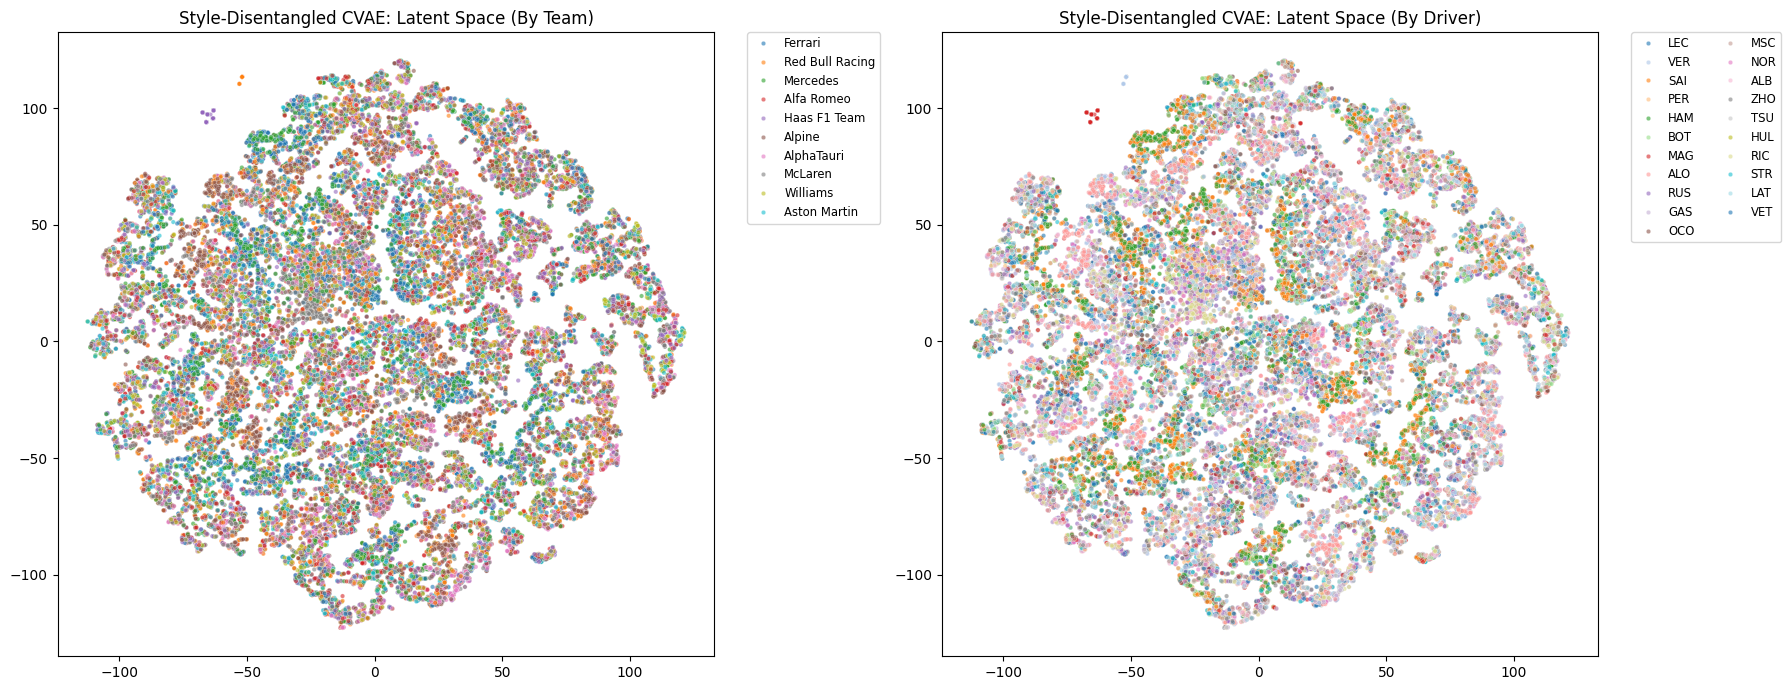


[3] Adversarial Probing
   Team probe accuracy (should be LOW if disentangled): 0.218
   Driver probe accuracy (should be HIGH if style retained): 0.171


In [ ]:
run_comprehensive_analysis(
    model_type="Style-Disentangled CVAE",
    embedder=model_cvae.encoder,
    dataset=full_dataset,
    team_names=teams,
    driver_names=drivers,
)